# ADSP 32018 IP01 Next-Gen NLP: Transformers, LLMs and AgenticAI in Practice - Final Project

## Part 3: Topic Modeling - BERTopic

**Objective of this Notebook:**

The purpose of this notebook is to uncover major themes in the cleaned news corpus using **BERTopic** and then translate those machine-discovered topics into a more interpretable **industry taxonomy**. This workflow combines transformer-based sentence embeddings, density-based clustering, and topic representation methods to identify coherent discussion patterns in AI-related news. After fitting the topic model, I map topic IDs to high-level industries using semantic similarity between topic embeddings and manually written industry anchor texts so that the outputs can support downstream trend analysis and business interpretation.

**Plan:**

- Load the cleaned and filtered document-level corpus produced in the earlier preprocessing steps.
- Prepare normalized input text for topic modeling and inspect sample rows to confirm that the modeling text is suitable for BERTopic.
- Configure and fit a **BERTopic** pipeline built on **SentenceTransformers** embeddings and clustering-based topic discovery.
- Inspect topic sizes, representative terms, and topic visualizations to evaluate whether the discovered themes are coherent and interpretable.
- Create document-level topic assignments and summarize the prevalence of major topics in the corpus.
- Build semantic embeddings for both topics and manually defined industry anchor texts.
- Map each BERTopic topic to the most similar industry label and merge that mapping back to the document level.
- Export the final topic-assigned dataset and summary tables for downstream industry, sentiment, and trend analysis.

## 0. Imports and Environment Setup

This section imports the libraries used throughout the notebook, including data manipulation tools, embedding models, visualization packages, and the BERTopic framework. These components together support text preprocessing, topic discovery, semantic similarity calculations, and exploratory evaluation of the learned topics.

In [ ]:
# import cuml
# cuml.accel.install()
import re

import pandas as pd
import numpy as np

# !pip install bertopic
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
import plotly.io as pio

## 1. Dataset Preparation

### 1.1 Load the cleaned corpus and inspect the available fields

This step loads the cleaned and relevance-filtered article dataset created earlier in the pipeline. The quick shape and column checks verify that the expected document-level fields are available before preparing the text used for topic modeling.

In [ ]:
clean_df = pd.read_parquet("./data/cleaned/news_clean_filtered.parquet")
print(f"Loaded rows: {len(clean_df)}")
print(f"Columns: {list(clean_df.columns)}")

required_cols = ["row_id", "title_clean", "text_clean_light"]
missing = [c for c in required_cols if c not in clean_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

Mounted at /content/drive
Loaded rows: 174826
Columns: ['row_id', 'date', 'language', 'title', 'title_clean', 'text', 'text_clean_light', 'url', 'char_count', 'token_count', 'alpha_ratio', 'high_signal_hits', 'support_hits', 'relevance_score', 'year', 'month']


### 1.2 Prepare normalized modeling text

BERTopic benefits from a consistent text field that removes obvious noise while preserving the semantic content of each article. The helper function below standardizes casing, strips URLs and markup-like artifacts, and creates a modeling-ready text representation that will be embedded and clustered in later steps.


In [ ]:
def normalize_for_topic_modeling(text: str) -> str:
    value = "" if pd.isna(text) else str(text)
    value = re.sub(r"https?://\S+|www\.\S+", " ", value)
    value = re.sub(r"<[^>]+>", " ", value)
    value = re.sub(r"[^A-Za-z0-9\s]", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


work_df = clean_df.copy()
work_df["model_text"] = work_df["text_clean_light"].fillna("").map(normalize_for_topic_modeling)

if "date" in work_df.columns:
    work_df["date"] = pd.to_datetime(work_df["date"], errors="coerce")
elif "date" in work_df.columns:
    work_df["date"] = pd.to_datetime(work_df["date"], errors="coerce")
else:
    work_df["date"] = pd.NaT

before_rows = len(work_df)
work_df = work_df.loc[work_df["model_text"].str.len() > 0].copy()
after_rows = len(work_df)

print(f"Rows before empty-text removal: {before_rows:,}")
print(f"Rows after empty-text removal: {after_rows:,}")
display(work_df[["title_clean", "model_text"]].head(3))

Rows before empty-text removal: 174,826
Rows after empty-text removal: 174,826


,title_clean,model_text
0,"Telecom giant KT to develop its own NPU, AI ec...",Telecom giant KT to develop its own NPU AI eco...
1,Garrison named one of ‘Washington’s Most Power...,Garrison named one of Washington s Most Powerf...
2,Instapundit » Blog Archive » HMM: An Advanced ...,Instapundit Blog Archive HMM An Advanced AI Ga...


### 1.3 Preview sample rows after normalization

This cell prints a small random sample so I can manually confirm that the cleaned modeling text still reflects the core content of the original articles. This kind of spot check helps catch normalization issues before fitting the topic model.


In [ ]:
sample_rows = work_df.sample(5, random_state=42)

for idx, row in sample_rows.iterrows():
    print(f"--- Row {idx} ---")
    print(f"ORIGINAL (text_clean_light):\n{row['text_clean_light'][:200]}...")
    print(f"MODEL TEXT (normalized):\n{row['model_text'][:200]}...")
    print("\n")

--- Row 103009 ---
ORIGINAL (text_clean_light):
How AI Can Enhance HR By Transforming Candidate And Employee ExperiencesSubscribe To NewslettersBETAThis is a BETA experience. You may opt-out by clicking hereMore From ForbesJun 10, 2024,08:15am EDT2...
MODEL TEXT (normalized):
How AI Can Enhance HR By Transforming Candidate And Employee ExperiencesSubscribe To NewslettersBETAThis is a BETA experience You may opt out by clicking hereMore From ForbesJun 10 2024 08 15am EDT20 ...


--- Row 166291 ---
ORIGINAL (text_clean_light):
RINGAI to GTQ: Convert Ring AI to Guatemalan Quetzal | Live RINGAI Price in GTQ | MEXCExchangeDEX+Buy CryptoMarketsSpotFutures500XEarnEventsMoreGold Bar & BTC Giveaway2000gRINGAI/GTQ: Access live Ring...
MODEL TEXT (normalized):
RINGAI to GTQ Convert Ring AI to Guatemalan Quetzal Live RINGAI Price in GTQ MEXCExchangeDEX Buy CryptoMarketsSpotFutures500XEarnEventsMoreGold Bar BTC Giveaway2000gRINGAI GTQ Access live Ring AI pric...


--- Row 111160 ---
ORIGINAL (text_

At the end of this section, the corpus has been loaded and converted into a cleaner text representation suitable for transformer-based topic modeling.


## 2. Configure and Fit the BERTopic Model

This section defines the main BERTopic pipeline and fits it to the prepared corpus. The goal is to learn document-level topic assignments and interpretable topic summaries from the AI-related article collection.


### 2.1 Define modeling configuration and embedding resources

Here I specify the random seed and the sentence-transformer model used to create document embeddings. These settings control both reproducibility and the semantic quality of the document representations used by BERTopic.


In [ ]:
RANDOM_STATE = 42

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

UMAP_N_COMPONENTS = 20
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.0

HDBSCAN_MIN_CLUSTER_SIZE = 200
HDBSCAN_MIN_SAMPLES = 15

TOP_N_WORDS = 15

MIN_TOPIC_SIZE = 100

VECTORIZER_PARAMS = {
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 15,
    "max_df": 0.90,
}

### 2.2 Fit BERTopic on the prepared corpus

This cell runs the main topic-modeling workflow. BERTopic uses transformer embeddings together with clustering and topic representation steps to discover recurring themes in the corpus and assign a topic ID to each document.


In [ ]:
fit_df = work_df.copy()

print(f"Fitting on rows: {len(fit_df)}")

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, trust_remote_code=True)

umap_model = UMAP(
    n_components=UMAP_N_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(**VECTORIZER_PARAMS)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    top_n_words=TOP_N_WORDS,
    min_topic_size=MIN_TOPIC_SIZE,
    verbose=True
)

fit_topics, fit_probs = topic_model.fit_transform(work_df["model_text"].tolist())

Fitting on rows: 174826


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-02-27 20:24:42,488 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/5464 [00:00<?, ?it/s]

2026-02-27 20:29:00,075 - BERTopic - Embedding - Completed ✓
2026-02-27 20:29:00,076 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-27 20:29:07,631 - BERTopic - Dimensionality - Completed ✓
2026-02-27 20:29:07,645 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-27 20:38:23,680 - BERTopic - Cluster - Completed ✓
2026-02-27 20:38:23,713 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-27 20:41:07,079 - BERTopic - Representation - Completed ✓


### 2.3 Save and reload the trained topic model

Persisting the trained model makes it easier to reuse the learned topic structure without having to refit the full pipeline every time. Reloading also helps verify that the saved model artifacts can be recovered correctly for later analysis.


In [ ]:
output_path = "./outputs/bertopic_model/bertopic_model"

try:
    topic_model.save(output_path, serialization="safetensors", save_ctfidf=True)
    print(f"Model saved successfully to {output_path} (format: safetensors)")
except Exception as e:
    print(f"Safetensors save failed ({e}); falling back to default pickle serialization.")
    topic_model.save(output_path, serialization="pickle", save_ctfidf=True)
    print(f"Model saved successfully to {output_path} (format: pickle)")

Model saved successfully to /content/drive/MyDrive/Colab Notebooks/final-project/BERTopic/bertopic_model (format: safetensors)


In [ ]:
# import os

# model_path = "./outputs/bertopic_model/bertopic_model"

# if os.path.exists(model_path):
#     print(f"Loading BERTopic model from {model_path}...")
#     # Note: If you saved with safetensors, the loader usually auto-detects,
#     # but explicit embedding_model passing is often safer to ensure the same base model is used.
#     topic_model = BERTopic.load(model_path, embedding_model=embedding_model)
#     print("Model loaded successfully.")
# else:
#     print(f"Model path {model_path} does not exist. Please ensure the model was saved.")

At this point, the notebook has produced a fitted BERTopic model and the corresponding topic assignments for the cleaned corpus.


## 3. Inspect Topic Quality and Build Document-Level Assignments

After fitting BERTopic, the next step is to evaluate whether the discovered topics are interpretable and useful. This section summarizes topic sizes, representative words, topic prevalence, and visualization outputs before constructing the document-level assignment table used downstream.


### 3.1 Review topic-level summaries and representative terms

This cell extracts BERTopic's topic information table and basic outlier statistics. It also prints topic representations so I can assess whether the largest discovered topics have meaningful and distinguishable keyword patterns.


In [ ]:
fit_topic_info_df = topic_model.get_topic_info()

fit_outlier_pct = (pd.Series(fit_topics) == -1).mean() * 100
n_non_outlier_topics = int((fit_topic_info_df["Topic"] != -1).sum())

print(f"Non-outlier topics discovered: {n_non_outlier_topics}")
print(f"Outlier share in fit sample: {fit_outlier_pct:.2f}%")
display(fit_topic_info_df.head(15))

Non-outlier topics discovered: 89
Outlier share in fit sample: 45.33%


,Topic,Count,Name,Representation,Representative_Docs
0,-1,79250,-1_gray_media group_gray media_prnewswire,"[gray, media group, gray media, prnewswire, pr...",[Cisco projects upbeat quarterly revenue as AI...
1,0,10595,0_gray media_gray_media group_prnewswire,"[gray media, gray, media group, prnewswire, te...",[Skip to contentNewsWeatherSportsLatest Newsca...
2,1,7371,1_jpeg_generated image_moreai_love hear,"[jpeg, generated image, moreai, love hear, dpi...",[Architecture landscape building outdoors AI P...
3,2,6810,2_benzinga_bank share_loan_penny,"[benzinga, bank share, loan, penny, pricebajaj...",[Should you still learn to code Godfather of A...
4,3,5490,3_patient_patients_drug_clinical,"[patient, patients, drug, clinical, medicine, ...",[Global Generative Artificial Intelligence AI ...
5,4,5252,4_amd_intel_chips_gpus,"[amd, intel, chips, gpus, ryzen, gpu, broadcom...",[Since a boom in artificial intelligence AI ki...
6,5,4884,5_aws_agentic_agentic ai_sap,"[aws, agentic, agentic ai, sap, ai agents, gen...",[Agentic AI systems capable of taking actions ...
7,6,3215,6_adobe_sora_firefly_ai art,"[adobe, sora, firefly, ai art, ai video, studi...",[Top AI Image Generators Software WebCatalogWe...
8,7,2152,7_4o_gpt 4o_chatgpt plus_o1,"[4o, gpt 4o, chatgpt plus, o1, o3, gpts, chatg...",[Like millions of others I use ChatGPT daily A...
9,8,2079,8_blockchain_presale_decentralized_ea,"[blockchain, presale, decentralized, ea, bitco...",[a16z From AI agents DePIN to micropayments 11...


In [ ]:
for topic_num in fit_topic_info_df.loc[fit_topic_info_df["Topic"] != -1, "Topic"]:
    topic_name = topic_model.get_topic(topic_num)
    topic_repr = topic_model.get_topic_info().loc[topic_model.get_topic_info()["Topic"] == topic_num, "Name"].values[0]
    topic_docs = topic_model.get_representative_docs(topic_num)

    print(f"Topic {topic_num}: {topic_repr}")
    print(f"Representation: {topic_name}")
    print(f"Representative Docs: {topic_docs[:200]}...")
    print("-" * 80)

Topic 0: 0_gray media_gray_media group_prnewswire
Representation: [('gray media', np.float64(0.1875358557744382)), ('gray', np.float64(0.18733363220558644)), ('media group', np.float64(0.185777587898026)), ('prnewswire', np.float64(0.18190538269585457)), ('television skip', np.float64(0.1811385228044884)), ('press release', np.float64(0.17369276493264454)), ('country music', np.float64(0.16375325288978226)), ('opinions statements', np.float64(0.16340408610506513)), ('prnewswire views', np.float64(0.1633767023257662)), ('courtesy prnewswire', np.float64(0.1633767023257662)), ('reflect gray', np.float64(0.1633767023257662)), ('endorsed gray', np.float64(0.1633767023257662)), ('necessarily state', np.float64(0.1633767023257662)), ('state reflect', np.float64(0.1633767023257662)), ('provided courtesy', np.float64(0.1633767023257662))]
Representative Docs: ['Skip to contentNewsWeatherSportsLatest NewscastLatest VideoBOGO FridaysContestsWeather CamsHomeNewsInternationalNationalPoliticsStateL

### 3.2 Build a document-level assignment table

This step attaches the learned topic IDs back to the document-level dataframe. The resulting assignment table becomes the main bridge between topic modeling outputs and the later industry-mapping and trend-analysis steps.


In [ ]:
assignments_df = work_df.copy()
assignments_df["topic_id"] = fit_topics

probs_arr = np.asarray(fit_probs)
if probs_arr.ndim == 1:
    assignments_df["topic_confidence"] = probs_arr
elif probs_arr.ndim == 2:
    assignments_df["topic_confidence"] = probs_arr.max(axis=1)
else:
    assignments_df["topic_confidence"] = np.nan

outlier_pct = (assignments_df["topic_id"] == -1).mean() * 100
print(f"Number of outliers: {(assignments_df['topic_id'] == -1).sum():,}")
print(f"Full-corpus outlier share: {outlier_pct:.2f}%")
print(f"Assigned rows: {len(assignments_df):,}")

Number of outliers: 79,250
Full-corpus outlier share: 45.33%
Assigned rows: 174,826


### 3.3 Summarize the concentration of the largest topics

This summary evaluates whether topic volume is dominated by only a few themes or distributed across a longer tail of medium and small topics. That helps judge how granular and balanced the learned topic structure is.


In [ ]:
top_10_topics = fit_topic_info_df.loc[fit_topic_info_df["Topic"] != -1].head(10)["Topic"].tolist()
top_20_topics = fit_topic_info_df.loc[fit_topic_info_df["Topic"] != -1].head(20)["Topic"].tolist()
assignments_df["is_top_10"] = assignments_df["topic_id"].map(lambda x: x in top_10_topics)
assignments_df["is_top_20"] = assignments_df["topic_id"].map(lambda x: x in top_20_topics)
top_10_coverage = assignments_df["is_top_10"].mean() * 100
top_20_coverage = assignments_df["is_top_20"].mean() * 100
print(f"Top 10 topics coverage: {top_10_coverage:.2f}%")
print(f"Top 20 topics coverage: {top_20_coverage:.2f}%")

Top 10 topics coverage: 28.47%
Top 20 topics coverage: 36.02%


The 10 largest topics together contain 28.68% of all assigned documents (including or excluding outliers depending on how I computed it upstream). The 20 largest topics together contain 35.49% of all documents. This looks like a moderate-to-long-tail distribution:

- No single set of topics is swallowing the corpus.
- There are many medium/small topics contributing meaningfully.

### 3.4 Count small topics and inspect the intertopic distance map

These diagnostics provide another check on topic quality. The small-topic count helps assess fragmentation, while the intertopic distance visualization shows whether topics are well separated or heavily overlapping in semantic space.


In [ ]:
small_topics_count = fit_topic_info_df.loc[(fit_topic_info_df["Topic"] != -1) & (fit_topic_info_df["Count"] < 200)].shape[0]
print(f"Number of small topics (<200 docs): {small_topics_count}")

Number of small topics (<200 docs): 0


In [ ]:
pio.renderers.default = "notebook_connected"
topic_model.visualize_topics()

There are one or two very dominant themes, shown by the largest bubbles, which likely capture broad Outlier/Unclustered topic. Many topics are clustered tightly near the center, meaning they are semantically similar and could be merged into higher-level categories because their boundaries are not very distinct. Several small topics sit far from the main cluster, which suggests niche or specialized themes that are easier to label but may contribute little volume and produce noisy time trends. Overall, the map suggests the topic landscape is moderately fragmented, so it’s better to analyze at the industry or macro-topic level and use confidence/thresholding rather than relying on fine-grained topic IDs as if they were cleanly separated.

## 4. Map BERTopic Topics to an Industry Taxonomy

Because BERTopic discovers latent themes rather than business labels, this section maps the learned topic IDs to a predefined industry taxonomy. The mapping is based on semantic similarity between topic embeddings and manually crafted industry anchor texts.

1. Document embeddings and topic assignments
   This cell loads a SentenceTransformer embedding model (MiniLM) on the GPU and prepares the inputs needed for topic-to-industry mapping. It extracts the corpus text from `work_df["model_text"]` into a list (`docs`) and reads the BERTopic topic assignment for each document (`doc_topics`). It then encodes every document into a normalized embedding vector (`doc_emb`), which will later be aggregated to represent each topic and compared against industry anchor embeddings.

In [ ]:
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")

docs = work_df["model_text"].astype(str).tolist()
doc_topics = np.array(topic_model.topics_)
doc_emb = embedder.encode(
    docs, batch_size=64, show_progress_bar=True, normalize_embeddings=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2732 [00:00<?, ?it/s]

2. Industry taxonomy and anchor texts
   This cell defines the target industry taxonomy that topic IDs will be mapped into. `industry_taxonomy` provides the set of industry labels (10 high-level categories) used for reporting and aggregation. `industry_anchors` provides multiple detailed “anchor descriptions” per industry that capture typical data sources, constraints, and use cases; these anchors serve as semantic prototypes that can be embedded and used as reference vectors when assigning each topic to the most similar industry.

In [ ]:
industry_anchors = {
    "Office and Administrative Support": [
        "AI is automating routine administrative tasks such as scheduling, document processing, email triage, and data entry through workflow automation and intelligent assistants.",
        "Generative AI tools are reshaping back-office operations by reducing clerical workload, improving information retrieval, and enabling fewer staff to handle higher volumes of administrative work."
    ],

    "Legal": [
        "AI is transforming legal services through document review automation, contract analysis, legal research assistants, and e-discovery powered by large language models.",
        "Law firms and corporate legal departments use AI to reduce research time, standardize compliance checks, and augment lawyers rather than fully replace legal judgment."
    ],

    "Architecture and Engineering": [
        "AI supports architecture and engineering by enabling generative design, automated simulations, and optimization of structural, mechanical, and energy-efficient systems.",
        "Machine learning models are used to accelerate design iteration, detect errors earlier, and integrate digital twins into planning and construction workflows."
    ],

    "Life, Physical, and Social Science": [
        "AI accelerates scientific discovery through data-driven modeling, pattern detection, and simulation across biology, chemistry, physics, and social sciences.",
        "Researchers apply machine learning to analyze large experimental datasets, automate hypothesis generation, and improve predictive accuracy in complex systems."
    ],

    "Business and Financial Operations": [
        "AI is widely adopted in finance and business operations for forecasting, fraud detection, risk modeling, pricing, and decision support.",
        "Automation and predictive analytics improve operational efficiency while shifting human roles toward oversight, strategy, and exception handling."
    ],

    "Community and Social Service": [
        "AI supports community and social services by improving case triage, resource allocation, and early risk detection for vulnerable populations.",
        "Decision-support tools help social workers prioritize interventions while raising ethical considerations around bias, transparency, and accountability."
    ],

    "Management": [
        "AI augments management functions by providing data-driven insights for planning, performance monitoring, and organizational decision-making.",
        "Executives use AI-powered dashboards and forecasting tools to optimize strategy, workforce allocation, and operational efficiency."
    ],

    "Sales and Related": [
        "AI is reshaping sales through customer segmentation, demand forecasting, recommendation systems, and automated lead scoring.",
        "Generative AI enhances sales productivity by assisting with outreach, proposal drafting, and customer interaction analysis."
    ],

    "Computer and Mathematical": [
        "AI plays a central role in computer and mathematical occupations, including machine learning development, data science, algorithm design, and applied optimization.",
        "Professionals in this field both build AI systems and use them to automate coding, analysis, and model experimentation."
    ],

    "Farming, Fishing, and Forestry": [
        "AI enables precision agriculture through crop monitoring, yield prediction, automated equipment, and environmental sensing.",
        "Machine learning helps optimize resource usage while reducing labor intensity and improving sustainability outcomes."
    ],

    "Protective Service": [
        "AI supports protective services through predictive policing tools, surveillance analytics, and real-time risk assessment systems.",
        "Automation improves situational awareness and response speed, while human oversight remains critical for ethical and legal accountability."
    ],

    "Healthcare Practitioners and Technical": [
        "AI assists healthcare practitioners with diagnostic imaging, clinical decision support, and patient risk stratification.",
        "These tools augment clinical expertise by improving accuracy and efficiency rather than fully replacing medical professionals."
    ],

    "Educational Instruction and Library": [
        "AI impacts education by enabling personalized learning, automated grading, tutoring systems, and content recommendation.",
        "Educators increasingly use AI tools to support instruction, assessment, and administrative tasks while redefining teaching roles."
    ],

    "Healthcare Support": [
        "AI automates healthcare support tasks such as scheduling, patient monitoring, documentation, and workflow coordination.",
        "Automation reduces administrative burden and allows support staff to focus on patient-facing and care coordination activities."
    ],

    "Arts, Design, Entertainment, Sports, and Media": [
        "Generative AI is transforming creative industries through automated content creation, design assistance, and media production tools.",
        "AI augments creative workflows while raising questions around originality, intellectual property, and labor displacement."
    ],

    "Personal Care and Service": [
        "AI has limited but growing impact on personal care services through scheduling tools, customer analytics, and service personalization.",
        "Most tasks remain human-centered, with AI primarily supporting logistics and operational efficiency."
    ],

    "Food Preparation and Serving Related": [
        "AI is applied in food services for demand forecasting, inventory optimization, and automated ordering systems.",
        "While some back-of-house tasks are automated, customer interaction and service delivery remain largely human-driven."
    ],

    "Transportation and Material Moving": [
        "AI affects transportation through route optimization, autonomous vehicles, predictive maintenance, and logistics planning.",
        "Automation improves efficiency and safety while gradually reshaping driver and operator roles."
    ],

    "Production": [
        "AI enables smart manufacturing through predictive maintenance, quality inspection, robotics, and process optimization.",
        "Machine learning systems increase throughput and consistency while reducing manual intervention in production lines."
    ],

    "Construction and Extraction": [
        "AI supports construction and extraction by improving site planning, equipment monitoring, safety analytics, and resource forecasting.",
        "Adoption is gradual due to physical constraints, regulatory requirements, and high reliance on skilled manual labor."
    ],

    "Installation, Maintenance, and Repair": [
        "AI assists maintenance and repair work through predictive diagnostics, sensor-based monitoring, and automated troubleshooting.",
        "Human technicians remain essential, with AI primarily enhancing efficiency and preventive maintenance."
    ],

    "Building and Grounds Cleaning and Maintenance": [
        "AI adoption in cleaning and grounds maintenance is limited but includes scheduling optimization, robotics, and facility monitoring.",
        "Most tasks remain manual, with AI improving planning and supervision rather than direct task execution."
    ]
}

3. Topic embeddings from representative documents (with fallback)
   This cell builds one embedding vector per topic so that topics can be compared directly to industry anchors. It collects all non-outlier topic IDs (excluding `-1`) and retrieves representative documents per topic from BERTopic (`rep_docs_map`). For each topic, it embeds up to 10 representative documents and averages them to form a topic centroid (`topic_vec`). If a topic has no representative documents, it falls back to averaging the embeddings of all documents assigned to that topic. Each topic vector is L2-normalized and stored in `topic_emb`, and `topic_emb_df` summarizes the topic ID, topic embedding, and the topic’s document count.

In [ ]:
topic_ids = sorted(set(doc_topics) - {-1})
topic_emb = {}
rep_docs_map = topic_model.get_representative_docs()

topic_emb = {}
for tid in topic_ids:
    rep_docs = rep_docs_map.get(tid, [])
    rep_docs = rep_docs[:10]

    if len(rep_docs) >= 1:
        rep_emb = embedder.encode(rep_docs, normalize_embeddings=True)
        topic_vec = rep_emb.mean(axis=0)
    else:
        idx = np.where(doc_topics == tid)[0]
        topic_vec = doc_emb[idx].mean(axis=0)

    topic_vec /= (np.linalg.norm(topic_vec) + 1e-12)
    topic_emb[tid] = topic_vec

topic_emb_df = pd.DataFrame({
    "topic_id": topic_ids,
    "topic_emb": [topic_emb[tid] for tid in topic_ids],
    "count": [(doc_topics == tid).sum() for tid in topic_ids]
})
display(topic_emb_df.head(10))

,topic_id,topic_emb,count
0,0,"[-0.0020431462, -0.03915586, -0.0009320104, 0....",10595
1,1,"[0.0034990055, -0.027380094, 0.031275794, -0.0...",7371
2,2,"[-0.056102432, -0.035786323, -0.037529107, 0.0...",6810
3,3,"[-0.0663485, -0.058345366, -0.014852715, -0.03...",5490
4,4,"[-0.052542597, -0.09792542, -0.015303687, -0.0...",5252
5,5,"[-0.079477265, -0.08930386, 0.009356651, 0.019...",4884
6,6,"[-0.07745291, -0.0053004497, -0.021316972, 0.0...",3215
7,7,"[-0.0864389, -0.06284001, -0.005216435, 0.0392...",2152
8,8,"[-0.08203022, -0.06122686, -0.033199955, -0.04...",2079
9,9,"[-0.101793796, -0.0653903, 0.039037615, -0.013...",1917


4. Industry anchor embeddings
   This cell converts each industry’s anchor texts into a single embedding vector that represents the industry in the same semantic space as the topics. For each industry label, it encodes the list of anchor descriptions and averages them to form one industry centroid vector. These industry vectors are stacked into `industry_emb` (shape K×384), which is used as the reference matrix for similarity matching.

In [ ]:
industry_names = [k for k in industry_anchors.keys() if k != "Other/Unclustered"]
industry_vecs = {}

for ind in industry_names:
    vecs = embedder.encode(industry_anchors[ind], normalize_embeddings=True)
    industry_vecs[ind] = vecs.mean(axis=0)

industry_emb = np.stack([industry_vecs[ind] for ind in industry_names], axis=0)

5. Topic-to-industry similarity and top-k candidates
   This cell computes cosine similarities between every topic embedding and every industry embedding and selects the best matches. It stacks the topic vectors into `topic_mat` and multiplies by the transpose of `industry_emb`; because both are normalized, the dot product approximates cosine similarity. For each topic, it extracts the top 3 most similar industries (`cand1–cand3`) along with their similarity scores (`score1–score3`). The result is stored in `topic_candidates_df`, sorted by topic prevalence, which supports both automatic mapping and manual review of ambiguous topics.

In [ ]:
topic_mat = np.stack(topic_emb_df["topic_emb"].values, axis=0)
sim = topic_mat @ industry_emb.T

topk = 3
top_idx = np.argsort(-sim, axis=1)[:, :topk]
top_scores = np.take_along_axis(sim, top_idx, axis=1)

candidates = []
for i, tid in enumerate(topic_emb_df["topic_id"].values):
    row = {
        "topic_id": int(tid),
        "count": int(topic_emb_df.loc[topic_emb_df["topic_id"] == tid, "count"].values[0]),
        "cand1": industry_names[top_idx[i, 0]],
        "score1": float(top_scores[i, 0]),
        "cand2": industry_names[top_idx[i, 1]],
        "score2": float(top_scores[i, 1]),
        "cand3": industry_names[top_idx[i, 2]],
        "score3": float(top_scores[i, 2]),
    }
    candidates.append(row)

topic_candidates_df = pd.DataFrame(candidates).sort_values("count", ascending=False)
topic_candidates_df.head(15)

,topic_id,count,cand1,score1,cand2,score2,cand3,score3
0,0,10595,Healthcare Support,0.322099,Healthcare Practitioners and Technical,0.269906,Personal Care and Service,0.255147
1,1,7371,"Arts, Design, Entertainment, Sports, and Media",0.389434,Architecture and Engineering,0.282941,Office and Administrative Support,0.281224
2,2,6810,Sales and Related,0.341485,"Arts, Design, Entertainment, Sports, and Media",0.298744,Legal,0.293602
3,3,5490,Healthcare Practitioners and Technical,0.598631,Healthcare Support,0.560814,Legal,0.536784
4,4,5252,Business and Financial Operations,0.392014,Management,0.385542,Sales and Related,0.326592
5,5,4884,Personal Care and Service,0.579154,Food Preparation and Serving Related,0.575936,Office and Administrative Support,0.570231
6,6,3215,"Arts, Design, Entertainment, Sports, and Media",0.443767,Office and Administrative Support,0.435071,Architecture and Engineering,0.393620
7,7,2152,Educational Instruction and Library,0.418497,Office and Administrative Support,0.416713,"Installation, Maintenance, and Repair",0.388270
8,8,2079,Legal,0.380147,Computer and Mathematical,0.345460,Business and Financial Operations,0.330359
9,9,1917,Educational Instruction and Library,0.454593,Legal,0.278166,Office and Administrative Support,0.257282


6. Apply the mapping back to document-level assignments
   This cell turns the candidate table into a final mapping by selecting the top candidate (`cand1`) as the assigned industry for each topic. It creates a `topic_to_industry` lookup table (topic_id → industry) and merges it into `assignments_df` so each document inherits an industry label based on its topic assignment. Finally, it forces outlier documents (`topic_id == -1`) to the `Other/Unclustered` bucket and displays a sample of document titles with their topic and industry labels for verification.

In [ ]:
topic_to_industry = topic_candidates_df[["topic_id", "cand1", "score1", "score2"]].copy()
topic_to_industry = topic_to_industry.rename(columns={"cand1": "industry"})

assignments_df = assignments_df.merge(
    topic_to_industry[["topic_id", "industry"]],
    on="topic_id",
    how="left"
)

assignments_df.loc[assignments_df["topic_id"] == -1, "industry"] = "Other/Unclustered"

display(assignments_df[["title_clean", "topic_id", "industry"]].head(10))

,title_clean,topic_id,industry
0,"Telecom giant KT to develop its own NPU, AI ec...",2,Sales and Related
1,Garrison named one of ‘Washington’s Most Power...,-1,Other/Unclustered
2,Instapundit » Blog Archive » HMM: An Advanced ...,-1,Other/Unclustered
3,5 Places to Start a Career in Data Science in ...,2,Sales and Related
4,Datametrex AI (CVE:DM) Trading Down 8% - Enter...,-1,Other/Unclustered
5,KBV Research: Increasing Government Initiative...,-1,Other/Unclustered
6,How do public officials make Land Bank decisio...,28,Computer and Mathematical
7,IARPA to Host Proposers' Day for HIATUS AI Sys...,41,Protective Service
8,LG’s New OLED TVs Will Use Chemistry and Machi...,2,Sales and Related
9,"""These children?"": Sodapoppin hilariously gets...",-1,Other/Unclustered


In [ ]:
top_5_topics = topic_candidates_df["topic_id"].tolist()
for tid in top_5_topics:
    sample_articles = assignments_df.loc[assignments_df["topic_id"] == tid].sample(5, random_state=RANDOM_STATE)
    industry = sample_articles["industry"].iloc[0]
    print(f"Topic {tid} - Assigned Industry: {industry}")
    for idx, row in sample_articles.iterrows():
        print(f"  - {row['title_clean']}...")
    print("-" * 80)

Topic 0 - Assigned Industry: Healthcare Support
  - Packers vs Commanders: Who will win NFL Week 2 game? AI predictions, team news, live streaming and more | Mint...
  - Nuvve Introduces Astrea AI Forecasting for Nordic Energy Market...
  - Innervate Unveils Next Generation of Industry's First Enterprise-Grade Generative AI Solution for Customer Experiences...
  - POLYN Technology, Edge Impulse Join Forces to Advance Tiny AI Products...
  - Windward's First-of-its-Kind AI Model Creates a New Standard of ETA Prediction Accuracy Critical to Mitigating Supply Chain Disruptions...
--------------------------------------------------------------------------------
Topic 1 - Assigned Industry: Arts, Design, Entertainment, Sports, and Media
  - Builder architecture working adult. AI | Premium Photo - rawpixel...
  - Wedding cake adult bride. AI | Free Photo - rawpixel...
  - Person light space adult. AI | Premium Photo Illustration - rawpixel...
  - Architecture hospital transportation electroni

The topic-to-industry mapping is working well for clearly domain-specific themes: topics centered on healthcare/life sciences, regulation and AI governance (e.g., EU AI Act and lawsuits), hardware and semiconductor supply chains, and entertainment use cases (e.g., music and media) are generally assigned to sensible industries and the representative titles align with the labels. At the same time, a noticeable share of topics remain “cross-industry” news types (AI product announcements, market/ETF coverage, general commentary, jobs/careers, and broad policy discussions), and these are often pulled into high-volume buckets like Retail/Consumer or Software/IT because those categories act as semantic catch-alls. This means the mapping is strong for specialized clusters but less reliable for mixed or generic clusters, so downstream prevalence and time-trend analyses will be more credible if I (i) apply a confidence or margin threshold to flag ambiguous topics for review and (ii) optionally add a small post-processing layer to route obvious market/regulatory/hardware signals to the appropriate industry. Overall, the results provide a solid, interpretable foundation for industry-level aggregation, with the main remaining work being to handle the general-news and multi-theme topics in a controlled way.

## 5. Build Summary Tables and Export Final Outputs

With industry labels merged back to the document level, the final step is to create the summary tables needed for downstream analysis and save the finished outputs for later notebooks.


### 5.1 Build topic prevalence and topic-by-month summary tables

These tables summarize how common each topic-industry combination is across the full corpus and over time. They are useful for reporting, plotting, and downstream temporal analysis.


In [ ]:
topic_prevalence_df = (
    assignments_df.groupby(["topic_id", "industry"], as_index=False)
    .size()
    .rename(columns={"size": "doc_count"})
    .sort_values("doc_count", ascending=False)
)
topic_prevalence_df["doc_share_pct"] = (
    topic_prevalence_df["doc_count"] / len(assignments_df) * 100
).round(2)

topic_month_df = (
    assignments_df.dropna(subset=["date"])
    .groupby(["month", "topic_id", "industry"], as_index=False)
    .size()
    .rename(columns={"size": "doc_count"})
)

display(topic_prevalence_df.head(15))
display(assignments_df[["row_id", "topic_id", "industry", "topic_confidence", "title_clean"]].head(5))

,topic_id,industry,doc_count,doc_share_pct
0,-1,Other/Unclustered,79250,45.33
1,0,Healthcare Support,10595,6.06
2,1,"Arts, Design, Entertainment, Sports, and Media",7371,4.22
3,2,Sales and Related,6810,3.90
4,3,Healthcare Practitioners and Technical,5490,3.14
5,4,Business and Financial Operations,5252,3.00
6,5,Personal Care and Service,4884,2.79
7,6,"Arts, Design, Entertainment, Sports, and Media",3215,1.84
8,7,Educational Instruction and Library,2152,1.23
9,8,Legal,2079,1.19


,row_id,topic_id,industry,topic_confidence,title_clean
0,2199,2,Sales and Related,1.000000,"Telecom giant KT to develop its own NPU, AI ec..."
1,69671,-1,Other/Unclustered,0.000000,Garrison named one of ‘Washington’s Most Power...
2,94772,-1,Other/Unclustered,0.000000,Instapundit » Blog Archive » HMM: An Advanced ...
3,96660,2,Sales and Related,0.971146,5 Places to Start a Career in Data Science in ...
4,117462,-1,Other/Unclustered,0.000000,Datametrex AI (CVE:DM) Trading Down 8% - Enter...


### 5.2 Aggregate prevalence at the industry level

This step collapses document assignments to the industry level so that I can compare how frequently each industry appears in AI-related news after the topic-to-industry mapping step.


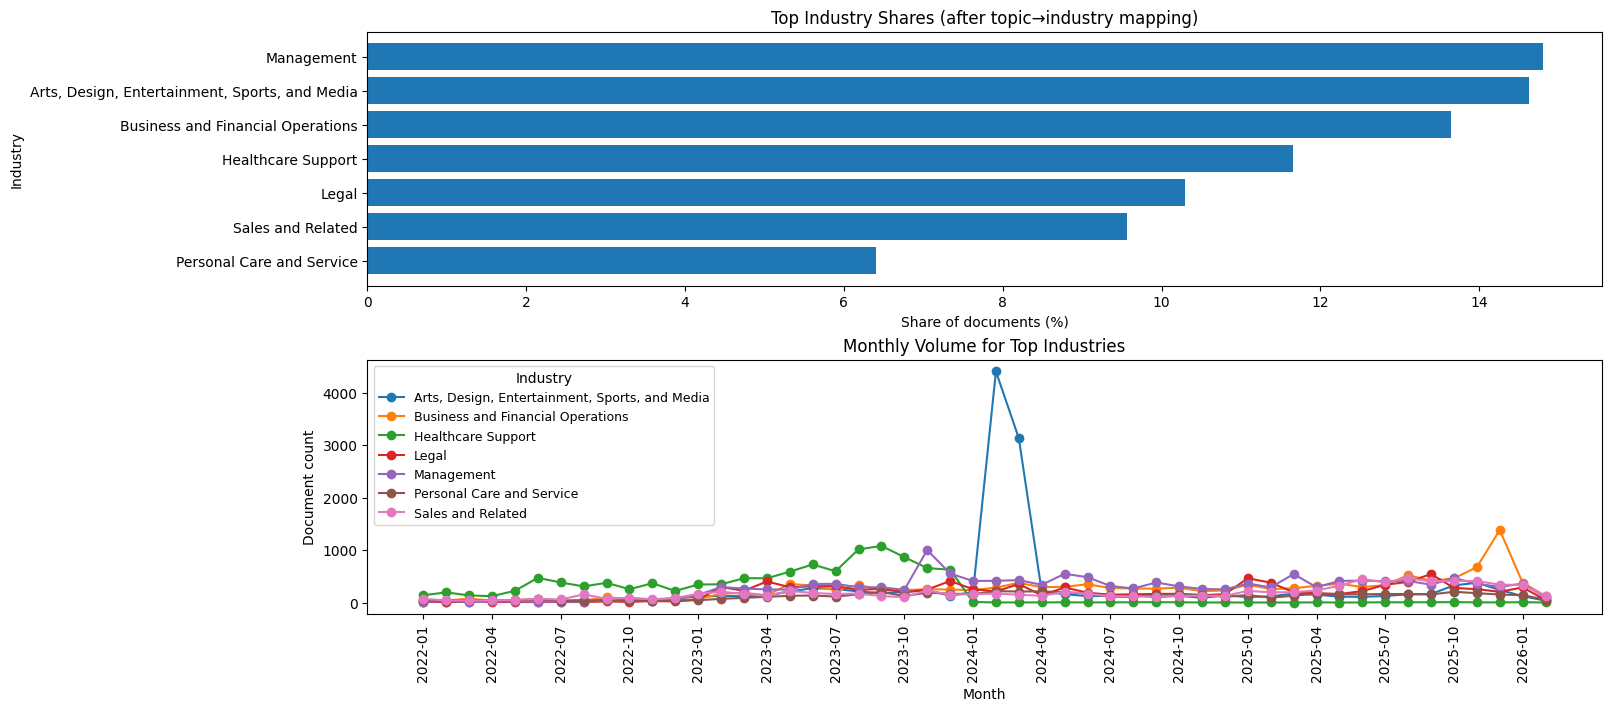

In [ ]:
df = assignments_df.copy()
df = df[df["topic_id"] != -1].copy()
industry_prevalence_df = (
    df.groupby("industry", as_index=False)
      .size()
      .rename(columns={"size": "doc_count"})
      .sort_values("doc_count", ascending=False)
)
industry_prevalence_df["doc_share_pct"] = (industry_prevalence_df["doc_count"] / len(df) * 100).round(2)

top_n = 7
top_industries = industry_prevalence_df["industry"].head(top_n).tolist()

df = df.dropna(subset=["date"]).copy()
df["month_key"] = df["date"].dt.tz_localize(None).dt.to_period("M").astype(str)

industry_month_df = (
    df[df["industry"].isin(top_industries)]
    .groupby(["month_key", "industry"], as_index=False)
    .size()
    .rename(columns={"size": "doc_count"})
)

industry_month_pivot = (
    industry_month_df.pivot(index="month_key", columns="industry", values="doc_count")
    .fillna(0)
    .sort_index()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), constrained_layout=True)

plot_bar = industry_prevalence_df.head(top_n).sort_values("doc_share_pct", ascending=True)
ax1.barh(plot_bar["industry"], plot_bar["doc_share_pct"])
ax1.set_title("Top Industry Shares (after topic→industry mapping)")
ax1.set_xlabel("Share of documents (%)")
ax1.set_ylabel("Industry")

industry_month_pivot.plot(ax=ax2, marker="o")
ax2.set_title("Monthly Volume for Top Industries")
ax2.set_xlabel("Month")
ax2.set_ylabel("Document count")

months = industry_month_pivot.index.tolist()
tick_idx = list(range(0, len(months), 3))
ax2.set_xticks(tick_idx)
ax2.set_xticklabels([months[i] for i in tick_idx], rotation=90)

ax2.legend(title="Industry", loc="upper left", fontsize=9)
plt.show()

### 5.3 Inspect the monthly topic table and export the final assignment dataset

The final checks confirm that the output tables have the expected structure before writing the document-level assignments to disk for use in later stages of the project.


In [ ]:
topic_month_df

,month,topic_id,industry,doc_count
0,2022-01,-1,Other/Unclustered,477
1,2022-01,0,Healthcare Support,136
2,2022-01,1,"Arts, Design, Entertainment, Sports, and Media",1
3,2022-01,2,Sales and Related,41
4,2022-01,3,Healthcare Practitioners and Technical,70
...,...,...,...,...
3563,2026-02,79,Management,4
3564,2026-02,82,"Arts, Design, Entertainment, Sports, and Media",2
3565,2026-02,83,Management,1
3566,2026-02,84,Business and Financial Operations,4


In [ ]:
assignments_df.to_parquet("./data/bertopic/bertopic_assigned.parquet/bertopic_assigned.parquet", index=False)

## Final Takeaway

This notebook turns a large corpus of AI-related news articles into an interpretable topic structure using BERTopic, then bridges those latent topics to a business-facing industry taxonomy through embedding-based similarity matching. The final output is a document-level dataset with topic and industry assignments that can support later entity extraction, sentiment modeling, and trend analysis.
